Iter 1: x = 0.35714285714285715, f(x) = -0.8473032069970845, f'(x) = 14.0, error = None (first step)
Iter 2: x = 0.44744814728501514, f(x) = -0.04761132557765535, f'(x) = 9.38265306122449, error = 0.20182291666666663
Iter 3: x = 0.453159435118196, f(x) = -0.00018435968901364674, f'(x) = 8.336355471536166, error = 0.01260326364316173
Iter 4: x = 0.4531817227771845, f(x) = -2.801860077283891e-09, f'(x) = 8.271828329255182, error = 4.918040130105329e-05
Iter 5: x = 0.453181723115918, f(x) = 0.0, f'(x) = 8.271576902697308, error = 7.474561934586011e-10
Root approximation (x0=0): 0.453181723115918 after 5 iterations


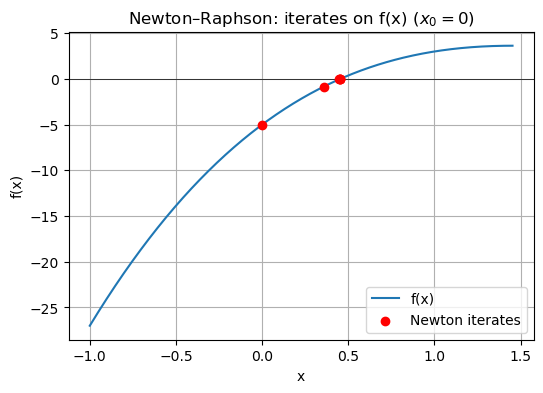

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# symbolic definitions
x_sym = sp.symbols('x')
f_sym = x_sym**3 - 7*x_sym**2 + 14*x_sym - 5
fprime_sym = sp.diff(f_sym, x_sym)
# numeric functions
f = sp.lambdify(x_sym, f_sym, 'numpy')
fprime = sp.lambdify(x_sym, fprime_sym, 'numpy')

def newton_from_zero():
    x0 = 0.0                  # fixed initial guess
    max_iter = int(input("Enter max number of iterations: "))
    precision = 1e-8

    x = float(x0)
    xs = [x]
    fs_vals = [f(x)]
    x_old = None
    for k in range(max_iter):
        fx = f(x)
        fpx = fprime(x)

        if fpx == 0:
            print(f"Derivative zero at x = {x}; stopping.")
            break

        x_new = x - fx / fpx
        fx_new = f(x_new)

        xs.append(x_new)
        fs_vals.append(fx_new)

        if x_old is None:
            rel_err = 0.0
            print(f"Iter {k+1}: x = {x_new}, f(x) = {fx_new}, "
                  f"f'(x) = {fpx}, error = None (first step)")
        else:
            rel_err = abs(x_new - x_old) / max(abs(x_new), 1e-16)
            print(f"Iter {k+1}: x = {x_new}, f(x) = {fx_new}, "
                  f"f'(x) = {fpx}, error = {rel_err}")

        if x_old is not None and rel_err < precision:
            print(f"Root approximation (x0=0): {x_new} after {k+1} iterations")
            break

        x_old = x_new
        x = x_new
    # plotting for this initial guess
    x_min = min(xs) - 1
    x_max = max(xs) + 1
    x_plot = np.linspace(x_min, x_max, 400)
    y_plot = f(x_plot)

    plt.figure(figsize=(6, 4))
    plt.axhline(0, color='black', linewidth=0.5)
    plt.plot(x_plot, y_plot, label='f(x)')
    plt.scatter(xs, fs_vals, color='red', zorder=3, label='Newton iterates')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True)
    plt.title('Newton–Raphson: iterates on f(x) ($x_0=0$)')
    plt.show()

newton_from_zero()
